In [106]:
# baseline model

In [107]:
# Load data + filter countries (>20 samples)

In [108]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def load_data(address):
    df = pd.DataFrame(pd.read_csv(address))
    return df
df = load_data('data/cost-of-living_v2.csv')
min_samples = 20
valid_country_names = df['country'].value_counts()
valid_country_names = valid_country_names[valid_country_names >= min_samples].index
filtered_df = df[df['country'].isin(valid_country_names)]

In [109]:
#Add column name

In [110]:
feature_names = [
    'Milk', 'Bread', 'Rice', 'Eggs', 'Local Cheese',
    'Chicken Fillets', 'Beef Round', 'Apples', 'Banana',
    'Oranges', 'Tomato', 'Potato', 'Onion', 'Lettuce',
    'Water', 'Bottle of Wine', 'Domestic Beer', 'Imported Beer'
]
grocery_cols = [f'x{i}' for i in range(9, 27)]
identity_cols = ['city', 'country']

grocery_df = filtered_df[identity_cols + grocery_cols].copy()
grocery_cols_features = {f'x{i}': name for i, name in zip(range(9, 27), feature_names)}
grocery_df = grocery_df.rename(columns=grocery_cols_features)

In [111]:
def count_the_missing_values_of_each_column(df):
    missing_values_series = df.isnull().sum()
    return missing_values_series

missing_values_series = count_the_missing_values_of_each_column(grocery_df)

In [112]:
grocery_df_imputed = grocery_df.fillna(grocery_df.mean(numeric_only=True))
missing_values_series = count_the_missing_values_of_each_column(grocery_df_imputed)
print(missing_values_series)

city               0
country            0
Milk               0
Bread              0
Rice               0
Eggs               0
Local Cheese       0
Chicken Fillets    0
Beef Round         0
Apples             0
Banana             0
Oranges            0
Tomato             0
Potato             0
Onion              0
Lettuce            0
Water              0
Bottle of Wine     0
Domestic Beer      0
Imported Beer      0
dtype: int64


In [113]:
# Price index

In [114]:
usd_df = grocery_df_imputed.copy()
usd_df['Total_Basket'] = usd_df[feature_names].sum(axis=1)
usa_baseline = usd_df[usd_df['country'] == 'United States']['Total_Basket'].median()
usd_df['Grocery_Price_Index'] = usd_df['Total_Basket'] / usa_baseline
grocery_df_imputed['Grocery_Price_Index'] = usd_df['Grocery_Price_Index']
grocery_df_imputed.head()

,city,country,Milk,Bread,Rice,Eggs,Local Cheese,Chicken Fillets,Beef Round,Apples,...,Oranges,Tomato,Potato,Onion,Lettuce,Water,Bottle of Wine,Domestic Beer,Imported Beer,Grocery_Price_Index
0,Seoul,South Korea,2.20,2.85,3.53,4.04,11.54,10.58,41.61,6.77,...,6.50,6.19,3.84,2.92,2.45,1.05,15.36,2.12,2.36,1.514960
1,Shanghai,China,2.74,2.61,1.22,2.22,18.35,4.86,13.12,2.26,...,2.19,1.53,0.84,1.04,0.83,0.64,14.24,0.94,1.97,0.855540
2,Guangzhou,China,1.91,1.63,1.03,1.71,9.00,3.77,11.75,2.02,...,1.82,1.31,0.74,1.00,0.49,0.51,11.39,0.95,2.26,0.639668
3,Mumbai,India,0.75,0.50,0.83,0.95,5.88,3.69,5.95,2.09,...,1.34,0.59,0.44,0.44,0.65,0.35,9.83,2.27,3.61,0.477209
4,Delhi,India,0.73,0.50,0.85,1.02,4.36,3.81,5.71,1.79,...,1.03,0.61,0.37,0.41,0.70,0.36,9.83,1.54,2.49,0.430809


In [115]:
#Split x,y

In [116]:
grocery_items = feature_names # The 18 items
macro_signal = ['Grocery_Price_Index'] # Macro

X_macro = grocery_df_imputed[macro_signal]
X_fingerprint = grocery_df_imputed[grocery_items]
X_full = grocery_df_imputed[grocery_items + macro_signal]
y = grocery_df_imputed['country']

In [117]:
#Baseline model

--- Results for: United States using Macro Only (Index) ---
Countries Most Similar to United States: 
Italy      27
France     23
Canada     23
Germany    19
Japan      15
Name: count, dtype: Int64


--- Results for: Italy using Macro Only (Index) ---
Countries Most Similar to Italy: 
United States     27
United Kingdom     7
Brazil             2
India              1
Name: count, dtype: Int64


--- Results for: India using Macro Only (Index) ---
Countries Most Similar to India: 
Brazil     22
Turkey     11
Poland      9
Ukraine     8
Romania     7
Name: count, dtype: Int64


--- Results for: Brazil using Macro Only (Index) ---
Countries Most Similar to Brazil: 
India          22
Russia          9
Mexico          8
Portugal        7
Philippines     7
Name: count, dtype: Int64


--- Results for: United Kingdom using Macro Only (Index) ---
Countries Most Similar to United Kingdom: 
United States    12
Russia           10
Germany           9
China             8
Italy             7
Name: co

<Figure size 800x600 with 0 Axes>

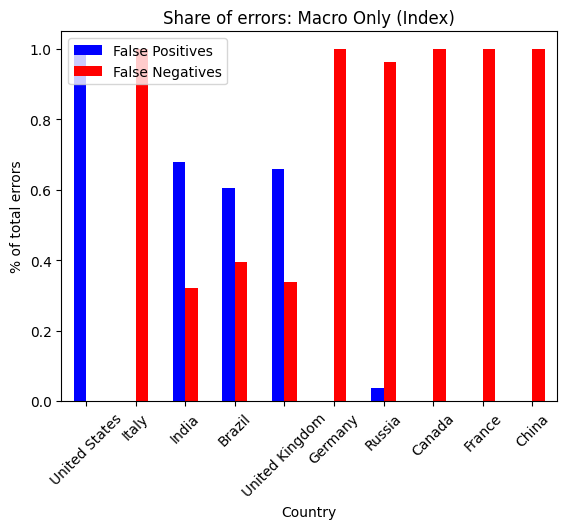

--- Results for: United States using Full Model (Both) ---
Countries Most Similar to United States: 
Australia    5
Canada       5
Finland      4
Japan        3
France       2
Name: count, dtype: Int64


--- Results for: Italy using Full Model (Both) ---
Countries Most Similar to Italy: 
France     8
Spain      3
Malta      2
Germany    2
Belgium    2
Name: count, dtype: Int64


--- Results for: India using Full Model (Both) ---
Countries Most Similar to India: 
United Kingdom    1
Pakistan          1
Belgium           1
Hungary           1
Name: count, dtype: Int64


--- Results for: Brazil using Full Model (Both) ---
Countries Most Similar to Brazil: 
Mexico            3
United Kingdom    2
South Africa      1
Chile             1
Hungary           1
Name: count, dtype: Int64


--- Results for: United Kingdom using Full Model (Both) ---
Countries Most Similar to United Kingdom: 
Ireland          2
Brazil           2
United States    2
Croatia          1
Australia        1
Name: count,

<Figure size 800x600 with 0 Axes>

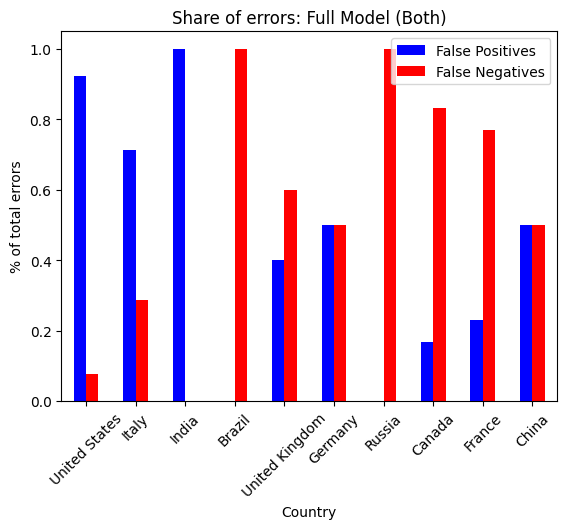

In [15]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

def printModel(df, actual, predictions):
    cm = confusion_matrix(actual, predictions)
    print('Confusion Matrix:\n',cm, '\n')

top_countries = y.value_counts().head(10).index
per_country_results = {}
feature_sets = {
    "Macro Only (Index)": X_macro,
    #"Fingerprint Only (Items)": X_fingerprint,
    "Full Model (Both)": X_full
}

for name, X_subset in feature_sets.items():
    #Split trainset and testset
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    #StandardScaler
    scaler_sub = StandardScaler()
    X_train_scaled = scaler_sub.fit_transform(X_train_sub)
    X_test_scaled = scaler_sub.transform(X_test_sub)

    # Train the same model family
    abl_model = LogisticRegression(max_iter=1000, random_state=42)
    abl_model.fit(X_train_scaled, y_train_sub)
    y_pred = abl_model.predict(X_test_scaled)

    #Top Confused Countries
    for country in top_countries:
        test = [x == country for x in y_test_sub]
        pred = [x == country for x in y_pred]
        falsePos = [x != country for x in y_pred[test]]
        falseNeg = [x != country for x in y_test_sub[pred]]
        print(f"--- Results for: {country} using {name} ---")
        print(f"Countries Most Similar to {country}: ")
        full = pd.array(np.append(y_test_sub[pred][falseNeg].to_numpy(),y_pred[test][falsePos]))
        print(full.value_counts().sort_values(ascending=False).head())

        print("\n")

    mask = y_test_sub.isin(top_countries)
    cm = confusion_matrix(
        y_test_sub[mask],
        y_pred[mask],
        labels=top_countries
    )

    fps = []
    fns = []
    per_country_results[name] = {}
    i = 0
    for country in top_countries:
        test = [x == country for x in y_test_sub]
        pred = [x == country for x in y_pred]
        country_cm = np.zeros((2, 2)).astype(int)
        country_cm[0][0] = cm[i][i]
        country_cm[0][1] = np.sum(cm[:, i]) - country_cm[0][0]
        country_cm[1][0] = np.sum(cm[i, :]) - country_cm[0][0]
        country_cm[1][1] = ((np.sum(cm) - country_cm[0][0]) - country_cm[0][1]) - country_cm[1][0]
        i += 1
        
        per_country_results[name].update({
            f"{country} Accuracy": accuracy_score(test, pred),
            f"{country} Macro F1": f1_score(test, pred, average='macro'),
            f"{country} True Positives": country_cm[0][0],
            f"{country} False Positives": country_cm[0][1],
            f"{country} False Negatives": country_cm[1][0],
            f"{country} True Negatives": country_cm[1][1]
        })

        sum = per_country_results[name][f"{country} False Positives"]+per_country_results[name][f"{country} False Negatives"]
        fps.append(per_country_results[name][f"{country} False Positives"] / sum)
        fns.append(per_country_results[name][f"{country} False Negatives"] / sum)

    pltdf = pd.DataFrame({'False Positives': fps,
                          "False Negatives": fns}, index=top_countries)

    plt.figure(figsize=(8, 6))
    ax = pltdf.plot.bar(rot=0, color={ "False Positives": "blue", 
                                      "False Negatives": "red"}, legend=True)
    plt.xticks(rotation=45)
    ax.set_title(f"Share of errors: {name}")
    ax.set_ylabel('% of total errors')
    ax.set_xlabel('Country')
    plt.show()